In [ ]:
!pip install nltk scikit-learn gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 140.3 MB/s eta 0:00:00


In [ ]:
!pip install scikit-learn keybert nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Import Libaries

import pandas as pd
import ast
import re
import string
import gensim
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import string
from keybert import KeyBERT
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import MultiLabelBinarizer
import os
import spacy

# Download required NLTK assets
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("maxent_ne_chunker")
nltk.download("words")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/aver

True

# **Import Data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datascience/Final Project/arxiv_data_210930-054931.csv')
df.head()

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


# **Structured Data Cleaning**

In [ ]:
# 1. Remove duplicate papers
df = df.drop_duplicates(subset=["titles", "abstracts"]).reset_index(drop=True)

In [ ]:
# 2. Handle missing titles and abstracts correctly
df["titles"] = df["titles"].fillna("Unknown Title").str.strip()
df["abstracts"] = df["abstracts"].fillna("No Abstract Available").str.strip()

In [ ]:
# 3. Normalize category labels (Convert string representation of lists to actual Python lists)
df["terms_list"] = df["terms"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [ ]:
# 4. Convert category codes into readable labels
CATEGORY_MAP = {
    # --- Core Machine Learning & AI Fields ---
    "cs.LG": "Machine Learning",
    "cs.AI": "Artificial Intelligence",
    "cs.CV": "Computer Vision",
    "cs.CL": "Natural Language Processing",
    "stat.ML": "Machine Learning / Statistics",

    # --- Computer Science Fields (cs.*) & Tech Mappings ---
    "cs.AR": "Hardware Architecture",
    "cs.CC": "Computational Complexity",
    "cs.CE": "Computational Engineering",
    "cs.CG": "Computational Geometry",
    "cs.CR": "Cryptography and Security",
    "cs.CY": "Computers and Society",
    "cs.DB": "Databases",
    "cs.DC": "Distributed and Parallel Computing",
    "cs.DL": "Digital Libraries",
    "cs.DM": "Discrete Mathematics",
    "cs.DS": "Data Structures and Algorithms",
    "cs.ET": "Emerging Technologies",
    "cs.FL": "Formal Languages and Automata",
    "cs.GR": "Computer Graphics",
    "cs.GT": "Game Theory",
    "cs.HC": "Human-Computer Interaction",
    "cs.IR": "Information Retrieval",
    "cs.IT": "Information Theory",
    "cs.LO": "Logic in Computer Science",
    "cs.MA": "Multiagent Systems",
    "cs.MM": "Multimedia",
    "cs.MS": "Mathematical Software",
    "cs.NA": "Numerical Analysis",
    "cs.NE": "Neural and Evolutionary Computing",
    "cs.NI": "Computer Networks",
    "cs.OH": "Other Computer Science",
    "cs.OS": "Operating Systems",
    "cs.PF": "Performance Evaluation",
    "cs.PL": "Programming Languages",
    "cs.RO": "Robotics",
    "cs.SC": "Symbolic Computation",
    "cs.SD": "Sound and Audio Processing",
    "cs.SE": "Software Engineering",
    "cs.SI": "Social and Information Networks",
    "cs.SY": "Systems and Control",
    "Computer science applications": "Computer Science Applications",
    "Computing methodologies for image processing": "Image Processing Methodologies",

    # --- Electrical Engineering & Signals (eess.*) ---
    "eess.AS": "Audio and Speech Processing",
    "eess.IV": "Image and Video Processing",
    "eess.SP": "Signal Processing",
    "eess.SY": "Systems and Control",

    # --- Statistics (stat.*) ---
    "stat.AP": "Applied Statistics",
    "stat.CO": "Statistical Computation",
    "stat.ME": "Statistical Methodology",
    "stat.OT": "Other Statistics",
    "stat.TH": "Statistical Theory",

    # --- Mathematics & Mathematical Physics (math.*) ---
    "math-ph": "Mathematical Physics",
    "math.AC": "Commutative Algebra",
    "math.AG": "Algebraic Geometry",
    "math.AP": "Analysis of PDEs",
    "math.AT": "Algebraic Topology",
    "math.CA": "Classical Analysis and ODEs",
    "math.CO": "Combinatorics",
    "math.CT": "Category Theory",
    "math.CV": "Complex Variables",
    "math.DG": "Differential Geometry",
    "math.DS": "Dynamical Systems",
    "math.FA": "Functional Analysis",
    "math.GN": "General Topology",
    "math.GR": "Group Theory",
    "math.GT": "Geometric Topology",
    "math.HO": "History and Overview of Mathematics",
    "math.IT": "Information Theory",
    "math.LO": "Mathematical Logic",
    "math.MG": "Metric Geometry",
    "math.MP": "Mathematical Physics",
    "math.NA": "Numerical Analysis",
    "math.NT": "Number Theory",
    "math.OA": "Operator Algebras",
    "math.OC": "Optimization and Control",
    "math.PR": "Probability",
    "math.RA": "Rings and Algebras",
    "math.RT": "Representation Theory",
    "math.SP": "Spectral Theory",
    "math.ST": "Statistical Theory",
    "ams": "Mathematics (AMS)",

    # --- Astrophysics (astro-ph.*) ---
    "astro-ph": "Astrophysics",
    "astro-ph.CO": "Cosmology",
    "astro-ph.EP": "Planetary Astrophysics",
    "astro-ph.GA": "Galactic Astrophysics",
    "astro-ph.HE": "High Energy Astrophysics",
    "astro-ph.IM": "Astrophysical Instrumentation",
    "astro-ph.SR": "Solar and Stellar Astrophysics",

    # --- Physics & Condensed Matter (physics.* / cond-mat.* / nlin.* / quant-ph) ---
    "quant-ph": "Quantum Physics",
    "cond-mat": "Condensed Matter Physics",
    "cond-mat.dis-nn": "Disordered Systems and Neural Networks",
    "cond-mat.mes-hall": "Mesoscale and Nanoscale Physics",
    "cond-mat.mtrl-sci": "Materials Science",
    "cond-mat.other": "Other Condensed Matter Physics",
    "cond-mat.soft": "Soft Condensed Matter",
    "cond-mat.stat-mech": "Statistical Mechanics",
    "cond-mat.str-el": "Strongly Correlated Electrons",
    "adap": "Adaptation and Self-Organizing Systems",
    "nlin.AO": "Adaptation and Self-Organizing Systems",
    "nlin.CD": "Chaotic Dynamics",
    "nlin.CG": "Cellular Automata",
    "nlin.PS": "Pattern Formation and Solitons",
    "nucl-ex": "Experimental Nuclear Physics",
    "nucl-th": "Theoretical Nuclear Physics",
    "physics.acc-ph": "Accelerator Physics",
    "physics.ao-ph": "Atmospheric and Oceanic Physics",
    "physics.app-ph": "Applied Physics",
    "physics.bio-ph": "Biological Physics",
    "physics.chem-ph": "Chemical Physics",
    "physics.class-ph": "Classical Physics",
    "physics.comp-ph": "Computational Physics",
    "physics.data-an": "Data Analysis",
    "physics.ed-ph": "Physics Education",
    "physics.flu-dyn": "Fluid Dynamics",
    "physics.geo-ph": "Geophysics",
    "physics.ins-det": "Instrumentation and Detectors",
    "physics.med-ph": "Medical Physics",
    "physics.optics": "Optics",
    "physics.plasm-ph": "Plasma Physics",
    "physics.pop-ph": "Popular Physics",
    "physics.soc-ph": "Physics and Society",
    "physics.space-ph": "Space Physics",

    # --- Quantitative Biology & Finance (q-bio.* / q-fin.* / econ.*) ---
    "q-bio.BM": "Biomolecules / Bioinformatics",
    "q-bio.CB": "Cell Behavior / Bioinformatics",
    "q-bio.GN": "Genomics / Bioinformatics",
    "q-bio.MN": "Molecular Networks / Bioinformatics",
    "q-bio.NC": "Neurons and Cognition / Bioinformatics",
    "q-bio.OT": "Other Quantitative Biology / Bioinformatics",
    "q-bio.PE": "Populations and Evolution / Bioinformatics",
    "q-bio.QM": "Quantitative Methods / Bioinformatics",
    "q-bio.TO": "Tissues and Organs / Bioinformatics",
    "q-fin.CP": "Computational Finance",
    "q-fin.EC": "Economics",
    "q-fin.GN": "General Finance",
    "q-fin.MF": "Mathematical Finance",
    "q-fin.PM": "Portfolio Management",
    "q-fin.PR": "Pricing of Securities",
    "q-fin.RM": "Risk Management",
    "q-fin.ST": "Statistical Finance",
    "q-fin.TR": "Trading and Market Microstructure",
    "econ.EM": "Econometrics",
    "econ.GN": "General Economics",
    "econ.TH": "Theoretical Economics"
}

df["readable_terms"] = df["terms_list"].apply(
    lambda tags: [CATEGORY_MAP.get(tag, tag) for tag in tags]
)

In [ ]:
# 5. Separate primary and secondary categories
df["primary_category"] = df["terms_list"].apply(
    lambda x: x[0] if len(x) > 0 else "Unknown"
)
df["secondary_categories"] = df["terms_list"].apply(
    lambda x: x[1:] if len(x) > 1 else []
)

In [ ]:
# 6. Create single-label targets (encoded integer values for the primary category)
df["single_label_target"] = df["primary_category"].astype("category").cat.codes

In [ ]:
# 7. Create multi-label targets (one-hot encoded binary matrix)
# Explode, get dummies, and regroup to create a binary vector for each row
multi_label_dummies = pd.get_dummies(df["terms_list"].explode()).groupby(level=0).sum()
df["multi_label_target"] = multi_label_dummies.values.tolist()

# Display the cleaned DataFrame
print(
    df[
        [
            "titles",
            "primary_category",
            "secondary_categories",
            "single_label_target",
            "multi_label_target",
        ]
    ].head()
)

                                              titles primary_category  \
0  Multi-Level Attention Pooling for Graph Neural...            cs.LG   
1  Decision Forests vs. Deep Networks: Conceptual...            cs.LG   
2  Power up! Robust Graph Convolutional Network v...            cs.LG   
3  Releasing Graph Neural Networks with Different...            cs.LG   
4  Recurrence-Aware Long-Term Cognitive Network f...            cs.LG   

  secondary_categories  single_label_target  \
0                   []                    1   
1              [cs.AI]                    1   
2     [cs.CR, stat.ML]                    1   
3              [cs.CR]                    1   
4                   []                    1   

                                  multi_label_target  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  

# **Text Cleaning**

In [ ]:
import re
import pandas as pd


def clean_text(text, lowercase=False):
    """Cleans text by removing noise, normalizing whitespace, handling LaTeX,

    and controlling letter case.
    """
    if not isinstance(text, str):
        return ""

    # 1. Handle LaTeX equations (e.g., $E=mc^2$ or $$math$$)
    # Replaces inline/block math with a uniform placeholder or removes it safely
    text = re.sub(r"\$\$.*?\$\$", " [MATH] ", text, flags=re.DOTALL)
    text = re.sub(r"\$.*?\$", " [MATH] ", text)

    # 2. Remove unnecessary symbols (keeps basic punctuation, letters, numbers)
    text = re.sub(r"[^\w\s\.,!?;\-\[\]]", "", text)

    # 3. Remove repeated punctuation (e.g., "!!!" -> "!", "..." -> ".")
    text = re.sub(r"([\.,!?;\-\[\]])\1+", r"\1", text)

    # 4. Normalize whitespace (removes tabs, newlines, and extra spaces)
    text = re.sub(r"\s+", " ", text).strip()

    # 5. Conditional lowercasing
    if lowercase:
        text = text.lower()

    return text


def preprocess_dataframe(df, lower_for_ml=False):
    """Cleans and combines 'titles' and 'abstracts' columns."""
    # Create a copy to avoid SettingWithCopyWarning
    processed_df = df.copy()

    # Clean individual columns
    processed_df["cleaned_title"] = processed_df["titles"].apply(
        lambda x: clean_text(x, lowercase=lower_for_ml)
    )
    processed_df["cleaned_abstract"] = processed_df["abstracts"].apply(
        lambda x: clean_text(x, lowercase=lower_for_ml)
    )

    # Combine title and abstract into a single input field
    processed_df["combined_input"] = (
        processed_df["cleaned_title"] + " " + processed_df["cleaned_abstract"]
    )

    return processed_df


# --- HOW TO RUN ---
df_traditional_ml = preprocess_dataframe(df, lower_for_ml=True)

# **Tokenization and Feature Engineering**

In [ ]:
def tokenize_and_lemmatize(text):
    """PERFORMS SENTENCE/WORD TOKENIZATION, REMOVES STOPWORDS, AND APPLIES LEMMATIZATION."""
    # 1. SENTENCE TOKENIZATION
    sentences = sent_tokenize(text)

    # 2. WORD TOKENIZATION (BUILT FROM THE GENERATED SENTENCES)
    words = []
    for sentence in sentences:
        words.extend(word_tokenize(sentence))

    # 3. BASE STOPWORDS FILTERING (NLTK + SKLEARN)
    nltk_stops = set(stopwords.words("english"))
    sklearn_stops = set(ENGLISH_STOP_WORDS)

    # 4. CUSTOM ACADEMIC NOISE FILTERING
    # INCLUDES COMMON JARGON FOUND IN PAPERS, PREPRINTS, AND RESEARCH CITATIONS
    academic_noise = {
        "abstract", "introduction", "conclusion", "references", "acknowledgement",
        "acknowledgements", "preprint", "manuscript", "fig", "figure", "table",
        "et", "al", "ibid", "pp", "vol", "edition", "chapter", "section",
        "appendix", "methodology", "results", "discussion", "author", "authors",
        "published", "cite", "citation", "journal", "proceedings", "conference"
    }

    # MERGE ALL STOP WORD SETS TO MINIMIZE ITERATION OVERHEAD
    combined_stop_words = nltk_stops.union(sklearn_stops).union(academic_noise)

    # KEEPING [MATH] PLACEHOLDER INTACT
    punctuation = set(string.punctuation) - {"[", "]"}

    filtered_words = [
        w for w in words if w.lower() not in combined_stop_words and w not in punctuation
    ]

    # 5. LEMMATIZATION
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(w) for w in filtered_words]

    return {
        "sentences": sentences,
        "tokens": words,
        "cleaned_lemmas": lemmatized_words,
    }


def extract_features(df, text_column):
    """EXECUTES THE COMPLETE FEATURE ENGINEERING PIPELINE ON THE DATAFRAME."""

    # APPLY TOKENIZATION AND LEMMATIZATION PIPELINE
    nlp_results = df[text_column].apply(tokenize_and_lemmatize)
    df["sentences"] = [res["sentences"] for res in nlp_results]
    df["tokens"] = [res["tokens"] for res in nlp_results]
    df["cleaned_lemmas"] = [res["cleaned_lemmas"] for res in nlp_results]

    # RECONSTRUCT CLEANED TEXT FOR VECTORIZERS
    cleaned_corpus = df["cleaned_lemmas"].apply(lambda x: " ".join(x))

    # 6. UNIGRAM, BIGRAM, TRIGRAM & DOMAIN TERM EXTRACTION VIA TF-IDF
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), min_df=2)
    tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_corpus)

    # 7. WORD2VEC EMBEDDINGS GENERATION
    w2v_model = Word2Vec(
        sentences=df["cleaned_lemmas"],
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
    )

    def get_doc_embedding(tokens, model):
        """AVERAGES WORD VECTORS TO GENERATE A SINGLE DOCUMENT-LEVEL EMBEDDING."""
        vectors = [model.wv[w] for w in tokens if w in model.wv]
        if not vectors:
            return np.zeros(model.vector_size)
        return np.mean(vectors, axis=0)

    # GENERATE DOCUMENT VECTORS
    df["w2v_embeddings"] = df["cleaned_lemmas"].apply(
        lambda x: get_doc_embedding(x, w2v_model)
    )

    return df, tfidf_matrix, tfidf_vectorizer, w2v_model

# --- HOW TO RUN ---
# Assuming 'df_traditional_ml' is from your previous text cleaning step:
df_features, tfidf_matrix, tfidf_vectorizer, w2v_model = extract_features(df_traditional_ml, 'combined_input')

In [ ]:
import gensim.downloader as api
import numpy as np
import pandas as pd

# --- 1. LOAD BOTH PRE-TRAINED MODELS ---
print("Downloading and loading GloVe (100d)...")
glove_model = api.load("glove-wiki-gigaword-100")

print("Downloading and loading FastText (300d)...")
fasttext_model = api.load("fasttext-wiki-news-subwords-300")


# --- 2. DEFINE EMBEDDING GENERATOR ---
def get_doc_embedding(tokens, model):
    """Averages pre-trained word vectors for tokens present in the model vocabulary."""
    vectors = []
    for token in tokens:
        clean_token = token.lower()
        if clean_token in model:
            vectors.append(model[clean_token])

    if not vectors:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# --- 3. GENERATE FEATURES FOR YOUR DATAFRAME ---
# Generate separate embedding arrays
df_features["glove_features"] = df_features["cleaned_lemmas"].apply(
    lambda x: get_doc_embedding(x, glove_model)
)

df_features["fasttext_features"] = df_features["cleaned_lemmas"].apply(
    lambda x: get_doc_embedding(x, fasttext_model)
)

# Combine both embeddings by concatenating them (creates a 400-dimensional vector)
df_features["combined_embeddings"] = df_features.apply(
    lambda row: np.concatenate([row["glove_features"], row["fasttext_features"]]),
    axis=1,
)

# --- 4. EXTRACT MATRICES FOR MACHINE LEARNING ---
X_glove = np.vstack(df_features["glove_features"].values)
X_fasttext = np.vstack(df_features["fasttext_features"].values)
X_combined = np.vstack(df_features["combined_embeddings"].values)

print(f"GloVe Matrix Shape:     {X_glove.shape}")  # (num_samples, 100)
print(f"FastText Matrix Shape:  {X_fasttext.shape}")  # (num_samples, 300)
print(f"Combined Matrix Shape:  {X_combined.shape}")  # (num_samples, 400)


[==================================================] 100.0% 128.1/128.1MB downloaded
[==================================================] 100.0% 958.5/958.4MB downloaded
GloVe Matrix Shape:     (41120, 100)
FastText Matrix Shape:  (41120, 300)
Combined Matrix Shape:  (41120, 400)


# **Label & Target Construction**

In [ ]:
# 1. Define the ArXiv-to-Domain Mapping Dictionary
# This covers the specific domains requested along with common ArXiv category codes
domain_mapping ={
    # ==========================================
    # 1. ARTIFICIAL INTELLIGENCE
    # ==========================================
    "cs.AI": "Artificial Intelligence",
    "Artificial intelligence": "Artificial Intelligence",
    "cs.MA": "Artificial Intelligence",  # Multiagent Systems
    "cs.GT": "Artificial Intelligence",  # Game Theory
    "adap": "Artificial Intelligence",    # Adaptation & Self-Organizing Systems
    "nlin.AO": "Artificial Intelligence",  # Adaptation Systems

    # ==========================================
    # 2. MACHINE LEARNING
    # ==========================================
    "cs.LG": "Machine Learning",
    "stat.ML": "Machine Learning  / Statistics",
    "cs.NE": "Machine Learning",  # Neural and Evolutionary Computing
    "cond-mat.dis-nn": "Machine Learning",  # Neural Networks in Physics

    # ==========================================
    # 3. COMPUTER VISION
    # ==========================================
    "cs.CV": "Computer Vision",

    # ==========================================
    # 4. NATURAL LANGUAGE PROCESSING
    # ==========================================
    "cs.CL": "Natural Language Processing",

    # ==========================================
    # 5. DATA SCIENCE
    # ==========================================
    "cs.DS": "Data Science",  # Data Structures and Algorithms
    "cs.DB": "Data Science",  # Databases
    "cs.IR": "Data Science",  # Information Retrieval
    "physics.data-an": "Data Science",  # Data Analysis
    "cs.DL": "Data Science",  # Digital Libraries
    "cs.SI": "Data Science",  # Social and Information Networks
    "astro-ph.IM": "Data Science",  # Astrophysical Instrumentation & Data
    "q-fin.ST": "Data Science",  # Statistical Finance
    "q-fin.TR": "Data Science",  # Trading and Market Microstructure

    # ==========================================
    # 6. CYBERSECURITY
    # ==========================================
    "cs.CR": "Cybersecurity",  # Cryptography and Security
    "cs.CY": "Cybersecurity",  # Computers and Society / Privacy
    "cs.NI": "Cybersecurity",  # Computer Networks
    "cs.AR": "Cybersecurity",  # Hardware Architecture (Hardware Security)

    # ==========================================
    # 7. STATISTICS
    # ==========================================
    "stat.AP": "Statistics",
    "stat.CO": "Statistics",
    "stat.ME": "Statistics",
    "stat.OT": "Statistics",
    "stat.TH": "Statistics",
    "stat.ST": "Statistics",
    "econ.EM": "Statistics",  # Econometrics

    # ==========================================
    # 8. MATHEMATICS
    # ==========================================
    "math-ph": "Mathematics",
    "ams": "Mathematics",
    "math.AC": "Mathematics", "math.AG": "Mathematics", "math.AP": "Mathematics",
    "math.AT": "Mathematics", "math.CA": "Mathematics", "math.CO": "Mathematics",
    "math.CT": "Mathematics", "math.CV": "Mathematics", "math.DG": "Mathematics",
    "math.DS": "Mathematics", "math.FA": "Mathematics", "math.GN": "Mathematics",
    "math.GR": "Mathematics", "math.GT": "Mathematics", "math.HO": "Mathematics",
    "math.IT": "Mathematics", "math.LO": "Mathematics", "math.MG": "Mathematics",
    "math.MP": "Mathematics", "math.NA": "Mathematics", "math.NT": "Mathematics",
    "math.OA": "Mathematics", "math.OC": "Mathematics", "math.PR": "Mathematics",
    "math.RA": "Mathematics", "math.RT": "Mathematics", "math.SP": "Mathematics",
    "math.ST": "Mathematics",
    "cs.CC": "Mathematics",  # Computational Complexity
    "cs.CG": "Mathematics",  # Computational Geometry
    "cs.DM": "Mathematics",  # Discrete Mathematics
    "cs.FL": "Mathematics",  # Formal Languages and Automata
    "cs.SC": "Mathematics",  # Symbolic Computation
    "cs.MS": "Mathematics",  # Mathematical Software
    "q-fin.MF": "Mathematics",  # Mathematical Finance
    "econ.TH": "Mathematics",  # Theoretical Economics

    # ==========================================
    # 9. BIOINFORMATICS
    # ==========================================
    "q-bio.BM": "Bioinformatics",  # Biomolecules
    "q-bio.CB": "Bioinformatics",  # Cell Behavior
    "q-bio.GN": "Bioinformatics",  # Genomics
    "q-bio.MN": "Bioinformatics",  # Molecular Networks
    "q-bio.NC": "Bioinformatics",  # Neurons and Cognition
    "q-bio.OT": "Bioinformatics",  # Other Quantitative Biology
    "q-bio.PE": "Bioinformatics",  # Populations and Evolution
    "q-bio.QM": "Bioinformatics",  # Quantitative Methods
    "q-bio.TO": "Bioinformatics",  # Tissues and Organs
    "physics.bio-ph": "Bioinformatics",  # Biological Physics

    # ==========================================
    # 10. ROBOTICS
    # ==========================================
    "cs.RO": "Robotics",
    "cs.SY": "Robotics",   # Systems and Control
    "eess.SY": "Robotics",  # Systems and Control
    "cs.DC": "Robotics",   # Distributed and Parallel Computing (Edge Swarms)
    "cs.CE": "Robotics",   # Computational Engineering

    # ==========================================
    # 11. MEDICAL IMAGING
    # ==========================================
    "physics.med-ph": "Medical Imaging",
    "Computing methodologies for image processing": "Medical Imaging",
    "eess.IV": "Medical Imaging",   # Image and Video Processing
    "eess.AS": "Medical Imaging",   # Audio and Speech Processing (Medical Ultrasound)
    "eess.SP": "Medical Imaging",   # Signal Processing (Biosignals / MRI reconstruction)
    "cs.SD": "Medical Imaging",    # Sound and Audio Processing
    "cs.GR": "Medical Imaging",    # Computer Graphics (3D Medical Rendering)
    "cs.MM": "Medical Imaging",    # Multimedia (Medical Video Streams)
    "physics.optics": "Medical Imaging",  # Optical Imaging

    # ==========================================
    # MISC FALLBACK EXTRACTIONS (Mapped to closest core field)
    # ==========================================
    "Computer science applications": "Data Science",
    "cs.ET": "Robotics",                       # Emerging Technologies
    "cs.OH": "Data Science",                    # Other Computer Science
    "cs.PF": "Data Science",                    # Performance Evaluation
    "cs.PL": "Data Science",                    # Programming Languages
    "cs.SE": "Data Science",                    # Software Engineering
    "q-fin.CP": "Data Science",                 # Computational Finance
    "q-fin.EC": "Data Science",                 # Financial Economics
    "q-fin.PM": "Data Science",                 # Portfolio Management
    "q-fin.PR": "Data Science",                 # Pricing of Securities
    "q-fin.RM": "Data Science",                 # Risk Management
    "econ.GN": "Data Science",                  # General Economics
    "astro-ph": "Mathematics", "astro-ph.CO": "Mathematics",
    "astro-ph.EP": "Mathematics", "astro-ph.GA": "Mathematics",
    "astro-ph.HE": "Mathematics", "astro-ph.SR": "Mathematics",
    "quant-ph": "Mathematics", "cond-mat": "Mathematics",
    "cond-mat.mes-hall": "Mathematics", "cond-mat.mtrl-sci": "Mathematics",
    "cond-mat.other": "Mathematics", "cond-mat.soft": "Mathematics",
    "cond-mat.stat-mech": "Mathematics", "cond-mat.str-el": "Mathematics",
    "nlin.CD": "Mathematics", "nlin.CG": "Mathematics",
    "nlin.PS": "Mathematics", "nucl-ex": "Mathematics",
    "nucl-th": "Mathematics", "physics.acc-ph": "Mathematics",
    "physics.ao-ph": "Mathematics", "physics.app-ph": "Mathematics",
    "physics.chem-ph": "Mathematics", "physics.class-ph": "Mathematics",
    "physics.comp-ph": "Mathematics", "physics.ed-ph": "Mathematics",
    "physics.flu-dyn": "Mathematics", "physics.geo-ph": "Mathematics",
    "physics.ins-det": "Mathematics", "physics.plasm-ph": "Mathematics",
    "physics.pop-ph": "Mathematics", "physics.soc-ph": "Mathematics",
    "physics.space-ph": "Mathematics", "cs.NA": "Mathematics"
}

def create_domain_labels(df, primary_col="primary_category"):
    """Maps primary category codes to broad research domains and creates unique ID flags."""
    # Copy dataframe to preserve original structure
    processed_df = df.copy()

    # 2. Extract base category groups (e.g., handles 'q-bio' prefixes generally if needed)
    def map_to_domain(cat):
        if not isinstance(cat, str):
            return "Other"
        # Exact match check
        if cat in domain_mapping:
            return domain_mapping[cat]
        # General prefix fallback checks (e.g., any q-bio category becomes Bioinformatics)
        if cat.startswith("q-bio"):
            return "Bioinformatics"
        if cat.startswith("math"):
            return "Mathematics"
        return "Other"

    # Apply mapping to generate text labels
    processed_df["primary_domain_label"] = processed_df[primary_col].apply(
        map_to_domain
    )

    # 3. Factorize text labels into unique numerical IDs
    # Sorting ensures numerical IDs remain consistent across script runs
    unique_labels = sorted(processed_df["primary_domain_label"].unique())
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}

    processed_df["Primary_domain_id"] = processed_df[
        "primary_domain_label"
  ].map(label_to_id)

    # Print mapping verification dictionary
    print("Generated Domain-to-ID Mapping Table:")
    for k, v in label_to_id.items():
        print(f"  ID {v} -> {k}")

    return processed_df


# --- HOW TO RUN ---
df_with_domains = create_domain_labels(df_traditional_ml, primary_col="primary_category")

Generated Domain-to-ID Mapping Table:
  ID 0 -> Computer Vision
  ID 1 -> Machine Learning
  ID 2 -> Machine Learning  / Statistics


In [ ]:
df_with_domains['primary_category'].value_counts()

,count
primary_category,
cs.CV,21629
cs.LG,16610
stat.ML,2881


In [ ]:
# ==========================================
# MULTI-LABEL TOPIC CONSTRUCTION
# ==========================================

def build_multi_label_targets(df, terms_list_col="terms_list"):
    """Converts ArXiv category lists into broad domain strings and binary label vectors."""
    # Reuse your established broad domain dictionary mapping
    from __main__ import domain_mapping  # Assumes domain_mapping dictionary exists

    processed_df = df.copy()

    # Step 1: Map raw codes inside list structures to broad strings
    def map_list_elements(cat_list):
        if not isinstance(cat_list, list):
            return []
        mapped_set = set()
        for cat in cat_list:
            if cat in domain_mapping:
                mapped_set.add(domain_mapping[cat])
            elif cat.startswith("q-bio"):
                mapped_set.add("Bioinformatics")
            elif cat.startswith("math"):
                mapped_set.add("Mathematics")
        return list(mapped_set)

    processed_df["multi_label_topics"] = processed_df[terms_list_col].apply(
        map_list_elements
    )

    # Step 2: Initialize MultiLabelBinarizer to create binary target vectors
    mlb = MultiLabelBinarizer()
    binary_matrix = mlb.fit_transform(processed_df["multi_label_topics"])

    # Convert the matrix into a list format per row matching your target requirement
    processed_df["multi_label_vector"] = list(binary_matrix)

    print("Detected Multi-Label Classes:")
    print(mlb.classes_)

    return processed_df, mlb, binary_matrix

# --- HOW TO RUN ---
df_multi, mlb_encoder, binary_matrix_output = build_multi_label_targets(df_with_domains, terms_list_col="terms_list")

Detected Multi-Label Classes:
['Artificial Intelligence' 'Bioinformatics' 'Computer Vision'
 'Cybersecurity' 'Data Science' 'Machine Learning'
 'Machine Learning  / Statistics' 'Mathematics' 'Medical Imaging'
 'Natural Language Processing' 'Robotics' 'Statistics']


In [ ]:
# ==========================================
# KEYWORD AND KEYPHRASE TARGET CONSTRUCTION
# ==========================================

# 1. LOAD HEAVY MODELS GLOBALLY ONCE
try:
    NLP = spacy.load("en_core_web_sm", disable=["ner", "textcat"])
except OSError:
    os.system("python -m spacy download en_core_web_sm")
    NLP = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

KW_MODEL = KeyBERT()

def build_keyword_targets_separated(df, text_col="abstracts", top_n=20, batch_size=64):
    """EXTRACTS KEY TERMS AND SEPARATES THEM INTO SINGLE-WORD KEYWORDS AND MULTI-WORD KEYPHRASES."""

    processed_df = df.copy()
    if text_col not in processed_df.columns:
        raise KeyError(f"COLUMN '{text_col}' NOT FOUND IN DATAFRAME.")

    # ENSURE ALL VALUES ARE STRINGS AND REPLACE NA VALUES
    corpus = processed_df[text_col].fillna("").astype(str).tolist()

    # 2. VECTORIZED TF-IDF EXTRACTION FOR THE ENTIRE CORPUS AT ONCE
    vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()

    # 3. BATCH KEYBERT INFERENCE (KEYPHRASE NGRAM RANGE ALLOWS BOTH)
    print("STARTING BATCH KEYBERT EXTRACTION...")
    bert_results = KW_MODEL.extract_keywords(
        corpus, keyphrase_ngram_range=(1, 3), stop_words="english", top_n=top_n * 2
    )

    # 4. PARALLEL MULTI-CORE SPACY PIPELINE FOR NOUN CHUNKS
    print("STARTING PARALLEL SPACY NOUN CHUNK EXTRACTION...")
    spacy_stops = NLP.Defaults.stop_words
    spacy_docs = NLP.pipe(corpus, batch_size=batch_size, n_process=-1)

    all_keywords = []
    all_keyphrases = []

    # 5. MERGE AND SEPARATE RESULTS BY WORD COUNT
    for idx, doc in enumerate(spacy_docs):
        combined_candidates = set()

        # A. MERGE TF-IDF TOP TERMS FOR CURRENT INDEX
        row_matrix = tfidf_matrix[idx].toarray()[0]
        top_indices = row_matrix.argsort()[-top_n:][::-1]
        for i in top_indices:
            if row_matrix[i] > 0:
                combined_candidates.add(feature_names[i].lower())

        # B. MERGE PRE-COMPUTED BATCH KEYBERT KEYPHRASES
        current_bert = bert_results[idx]
        for kw, score in current_bert:
            combined_candidates.add(kw.lower())

        # C. MERGE SPACY NOUN PHRASES
        noun_chunks = [
            chunk.text.lower().strip()
            for chunk in doc.noun_chunks
            if len(chunk.text.strip()) > 2
            and chunk.text.lower() not in spacy_stops
        ]
        combined_candidates.update(noun_chunks[:top_n])

        # D. SPLIT COMBINED TERMS INTO KEYWORDS (1 WORD) AND KEYPHRASES (2+ WORDS)
        keywords_set = set()
        keyphrases_set = set()

        for term in combined_candidates:
            word_count = len(term.split())
            if word_count == 1:
                keywords_set.add(term)
            elif word_count > 1:
                keyphrases_set.add(term)

        # CONVERT TO SORTED LISTS AND CAP AT TOP_N FOR BALANCED OUTPUTS
        all_keywords.append(list(keywords_set)[:top_n])
        all_keyphrases.append(list(keyphrases_set)[:top_n])

    # ASSIGN TO THE TWO REQUISITE COLUMNS
    processed_df["keywords"] = all_keywords
    processed_df["keyphrases"] = all_keyphrases

    return processed_df

# --- EXECUTION ---
final_df = build_keyword_targets_separated(df_multi, text_col="abstracts", top_n=20, batch_size=64)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

STARTING BATCH KEYBERT EXTRACTION...
STARTING PARALLEL SPACY NOUN CHUNK EXTRACTION...


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41120 entries, 0 to 41119
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   terms                 41120 non-null  object
 1   titles                41120 non-null  object
 2   abstracts             41120 non-null  object
 3   terms_list            41120 non-null  object
 4   readable_terms        41120 non-null  object
 5   primary_category      41120 non-null  object
 6   secondary_categories  41120 non-null  object
 7   single_label_target   41120 non-null  int8  
 8   multi_label_target    41120 non-null  object
 9   cleaned_title         41120 non-null  object
 10  cleaned_abstract      41120 non-null  object
 11  combined_input        41120 non-null  object
 12  sentences             41120 non-null  object
 13  tokens                41120 non-null  object
 14  cleaned_lemmas        41120 non-null  object
 15  w2v_embeddings        41120 non-null

# **Exploratory Data Analysis**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import combinations
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS

--- Running 4.1 Category-Based EDA ---


/tmp/ipykernel_16222/3242974441.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


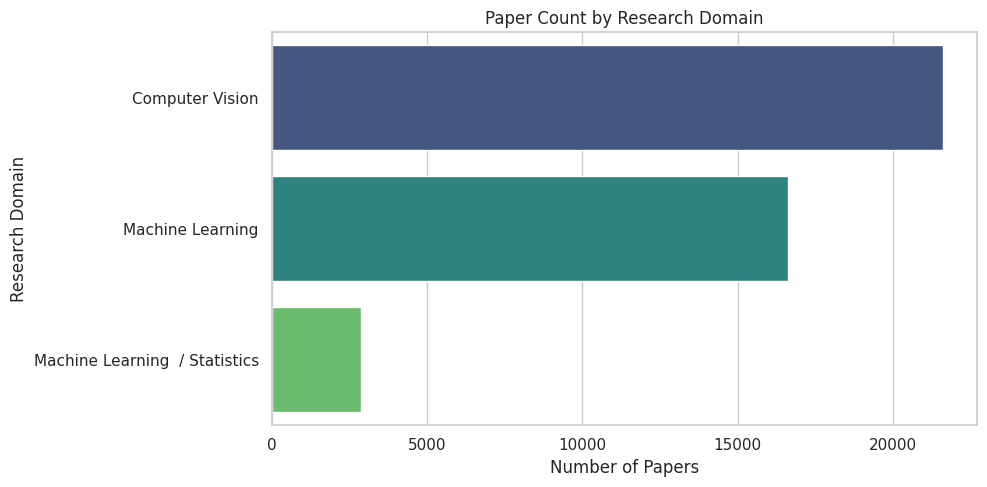

/tmp/ipykernel_16222/3242974441.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


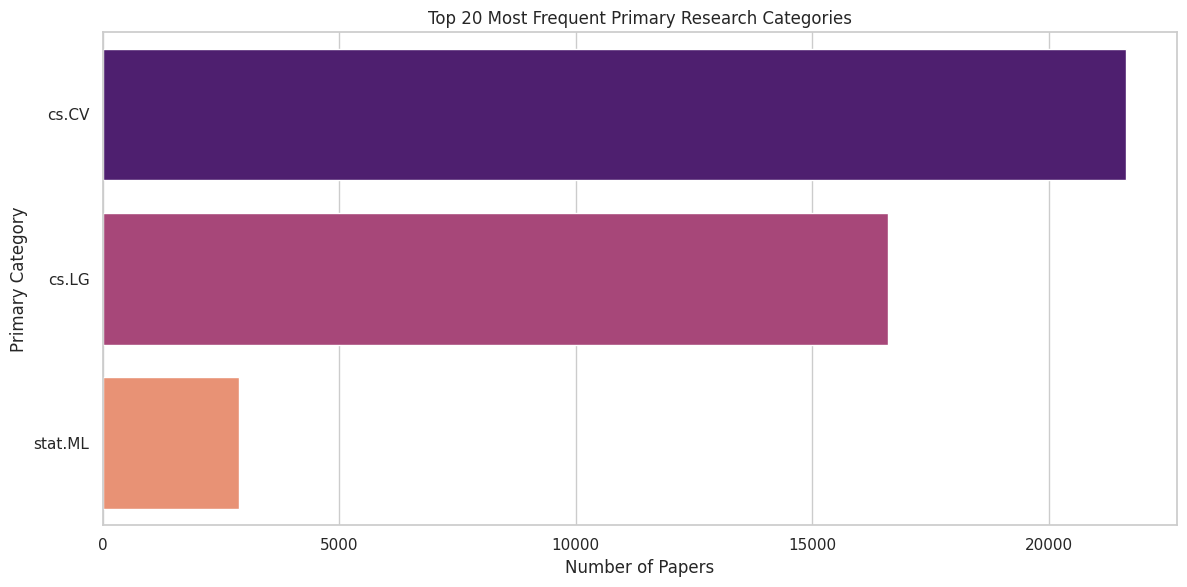


Top 5 Multi-Label Category Combinations:
  ('cs.AI', 'stat.ML'): 1242 papers
  ('cs.LG', 'eess.IV'): 599 papers
  ('cs.CV', 'stat.ML'): 528 papers
  ('cs.AI', 'cs.LG'): 493 papers
  ('cs.LG', 'stat.ML'): 345 papers

Top 5 Interdisciplinary Category Pairs:
  cs.AI <--> stat.ML: 2041 overlaps
  cs.CV <--> stat.ML: 920 overlaps
  cs.AI <--> cs.LG: 889 overlaps
  cs.LG <--> eess.IV: 860 overlaps
  cs.LG <--> stat.ML: 540 overlaps


In [17]:
# Set styling for clean, readable plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12})

# =====================================================================
# 4.1 Category-Based EDA
# =====================================================================
print("--- Running 4.1 Category-Based EDA ---")

# 1. Visualize paper count by research domain
plt.figure(figsize=(10, 5))
sns.countplot(
    data=final_df,
    y="primary_domain_label",
    order=final_df["primary_domain_label"].value_counts().index,
    palette="viridis",
)
plt.title("Paper Count by Research Domain")
plt.xlabel("Number of Papers")
plt.ylabel("Research Domain")
plt.tight_layout()
plt.show()

# 2. Identify most frequent research categories & 3. Analyze primary category distribution
plt.figure(figsize=(12, 6))
top_categories = final_df["primary_category"].value_counts().head(20)
sns.barplot(
    x=top_categories.values, y=top_categories.index, palette="magma"
)
plt.title("Top 20 Most Frequent Primary Research Categories")
plt.xlabel("Number of Papers")
plt.ylabel("Primary Category")
plt.tight_layout()
plt.show()

# 4. Analyze multi-label category combinations
# Cleans string representation of lists if necessary
def ensure_list(val):
    # 1. Handle NumPy arrays first to avoid truth value ambiguity errors
    if isinstance(val, np.ndarray):
        return val.tolist()

    # 2. Handle actual Python lists
    if isinstance(val, list):
        return val

    # 3. Handle missing/null values safely
    if pd.isna(val) or val is None:
        return []

    # 4. Handle text string lists or plain phrases
    if isinstance(val, str):
        val = val.strip()
        if not val:
            return []
        try:
            parsed = ast.literal_eval(val)
            return parsed if isinstance(parsed, list) else [parsed]
        except Exception:
            if "," in val:
                return [item.strip() for item in val.split(",") if item.strip()]
            return [val]

    # Fallback for any other individual scalar data types
    return [val]


final_df["clean_secondary"] = final_df["secondary_categories"].apply(
    ensure_list
)

combo_counter = Counter()
pair_counter = Counter()

for seq in final_df["clean_secondary"]:
    # Sort to ensure order doesn't create duplicate unique pairs/combinations
    sorted_cats = sorted([str(c) for c in seq if c])
    if len(sorted_cats) > 1:
        # Full combination tracking
        combo_counter[tuple(sorted_cats)] += 1
        # 5. Top interdisciplinary category pairs
        for pair in combinations(sorted_cats, 2):
            pair_counter[pair] += 1

print("\nTop 5 Multi-Label Category Combinations:")
for combo, count in combo_counter.most_common(5):
    print(f"  {combo}: {count} papers")

print("\nTop 5 Interdisciplinary Category Pairs:")
for pair, count in pair_counter.most_common(5):
    print(f"  {pair[0]} <--> {pair[1]}: {count} overlaps")


--- Running 4.2 Abstract-Based EDA ---


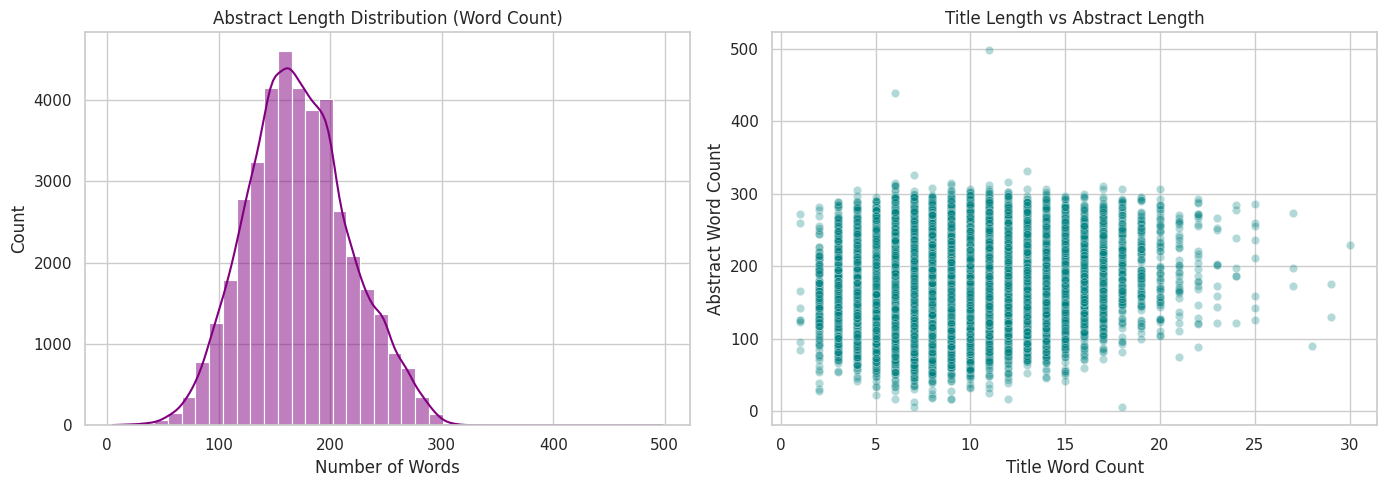

/tmp/ipykernel_16222/402411686.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


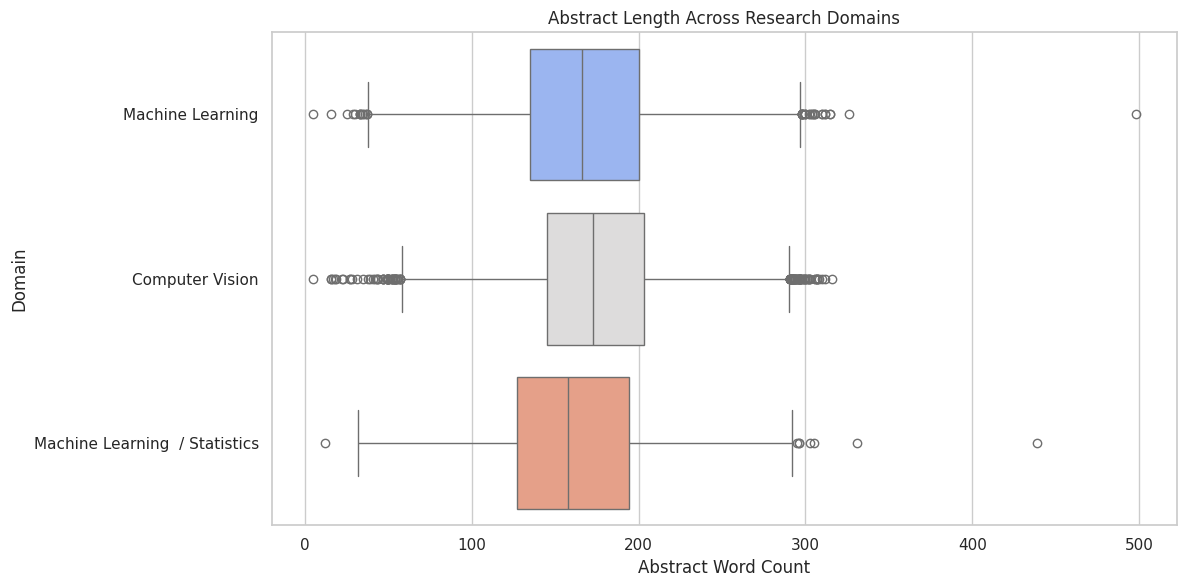

Found 413 unusually short abstracts (≤ 72 words).
Found 427 unusually long abstracts (≥ 280 words).


In [4]:
# =====================================================================
# 4.2 Abstract-Based EDA
# =====================================================================
print("\n--- Running 4.2 Abstract-Based EDA ---")

# Calculate lengths
final_df["abstract_len"] = final_df["cleaned_abstract"].astype(str).apply(
    lambda x: len(x.split())
)
final_df["title_len"] = final_df["cleaned_title"].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot abstract length distribution
sns.histplot(
    final_df["abstract_len"], bins=40, kde=True, ax=axes[0], color="purple"
)
axes[0].set_title("Abstract Length Distribution (Word Count)")
axes[0].set_xlabel("Number of Words")

# 3. Analyze title length vs abstract length
sns.scatterplot(
    data=final_df,
    x="title_len",
    y="abstract_len",
    alpha=0.3,
    ax=axes[1],
    color="teal",
)
axes[1].set_title("Title Length vs Abstract Length")
axes[1].set_xlabel("Title Word Count")
axes[1].set_ylabel("Abstract Word Count")
plt.tight_layout()
plt.show()

# 2. Compare abstract length across domains
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=final_df,
    x="abstract_len",
    y="primary_domain_label",
    palette="coolwarm",
    orient="h",
)
plt.title("Abstract Length Across Research Domains")
plt.xlabel("Abstract Word Count")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()

# 4. Identify papers with very short or very long abstracts (Anomalies)
# Using 1st and 99th percentiles as thresholds
short_thresh = final_df["abstract_len"].quantile(0.01)
long_thresh = final_df["abstract_len"].quantile(0.99)

short_papers = final_df[final_df["abstract_len"] <= short_thresh]
long_papers = final_df[final_df["abstract_len"] >= long_thresh]

print(
    f"Found {len(short_papers)} unusually short abstracts (≤ {int(short_thresh)} words)."
)
print(
    f"Found {len(long_papers)} unusually long abstracts (≥ {int(long_thresh)} words)."
)


--- Running 4.3 Text-Centric EDA ---

Generating Normalized Domain Word Clouds...


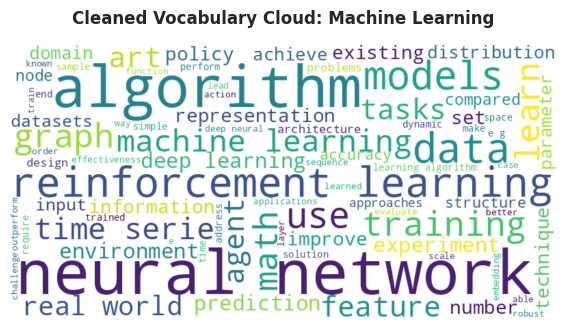

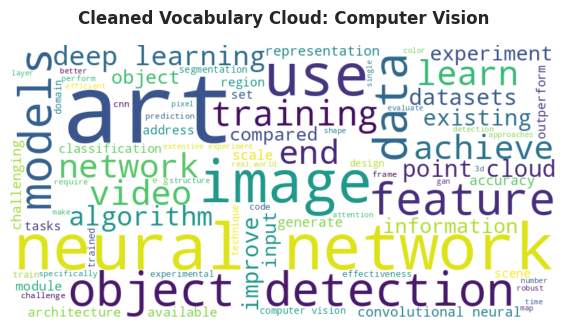

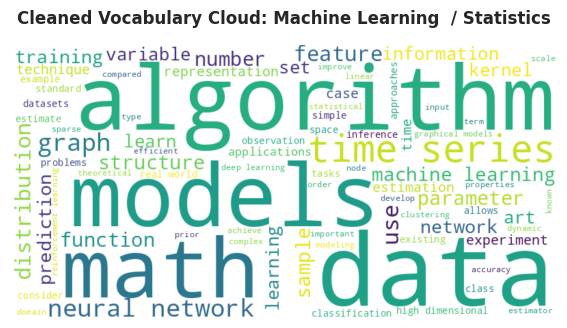






Top 5 Domain-Specific TF-IDF Technical Terms Per Domain:
  📍 Machine Learning            : learning, data, graph, models, time
  📍 Computer Vision             : image, learning, object, data, detection
  📍 Machine Learning  / Statistics: data, learning, models, time, math


In [5]:
# =====================================================================
# 4.3 Text-Centric EDA
# =====================================================================
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

print("\n--- Running 4.3 Text-Centric EDA ---")

# 1. Define an aggressive, comprehensive academic noise filter list
academic_noise = [
    "paper", "propose", "method", "results", "using", "study", "approach", "system", "abstract",
    "model", "methods", "based", "proposed", "used", "provide", "present", "different",
    "demonstrate", "introduce", "allow", "work", "new", "application", "performance",
    "dataset", "framework", "setting", "analysis", "given", "show", "shown", "task", "problem",
    "highly", "particular", "general", "finally", "various", "multiple", "large", "novel", "images","state","effective"
]
# Combine standard English stopwords with your aggressive academic filter list
custom_stop_words = list(set(ENGLISH_STOP_WORDS).union(academic_noise))

# Safely extract unique domains dropping any accidental NaN properties
domains = [d for d in final_df["primary_domain_label"].dropna().unique() if str(d).strip()]

# FIX 1: Loop and render word clouds sequentially instead of stacking everything
# inside a massive subplots grid to prevent Out-Of-Memory memory allocation crashes.
print("\nGenerating Normalized Domain Word Clouds...")
for domain in domains:
    domain_text = " ".join(
        final_df[final_df["primary_domain_label"] == domain]["cleaned_abstract"].astype(str)
    )

    if domain_text.strip():
        # Instantiate WordCloud parsing configurations with custom stopwords
        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            max_words=80,
            stopwords=set(custom_stop_words)
        ).generate(domain_text)

        # 1. Instantiate the figure window canvas
        fig, ax = plt.subplots(figsize=(8, 4))

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Cleaned Vocabulary Cloud: {domain}", fontsize=12, weight="bold", pad=15)
        ax.axis("off")

        # 2. Force layout padding adjustments to decouple boundary boxes
        plt.tight_layout(pad=3.0)  # Injects explicit structural layout padding bounds

        # 3. Render canvas onto screen
        plt.show()

        # 4. Ingest an explicit line break separation gap into the console runtime track
        print("\n\n" + "="*80 + "\n\n")


# 2. Extract top TF-IDF terms per domain
# 3. Identify frequent technical terms & 4. Compare keywords across domains
print("\nTop 5 Domain-Specific TF-IDF Technical Terms Per Domain:")
for domain in domains:
    domain_corpus = final_df[final_df["primary_domain_label"] == domain]["cleaned_abstract"].astype(str)

    if not domain_corpus.empty and domain_corpus.str.strip().any():
        # FIX 3: Increased max_features to 2000 so the model evaluates the broad vocabulary
        # landscape before isolating the top distinct technical terms, filtered by custom stopwords.
        vectorizer = TfidfVectorizer(max_features=2000, stop_words=custom_stop_words, ngram_range=(1, 2))
        tfidf_matrix = vectorizer.fit_transform(domain_corpus)

        # Sum TF-IDF scores across all documents in this domain
        scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
        words = vectorizer.get_feature_names_out()

        # Sort and extract top indices dynamically
        top_indices = scores.argsort()[::-1][:5]
        top_terms = [words[idx] for idx in top_indices]
        print(f"  📍 {domain:<28}: {', '.join(top_terms)}")



--- Running 4.4 Keyword and Keyphrase EDA ---


/tmp/ipykernel_16222/2269486304.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_kws, x="Count", y="Keyword", palette="plasma")


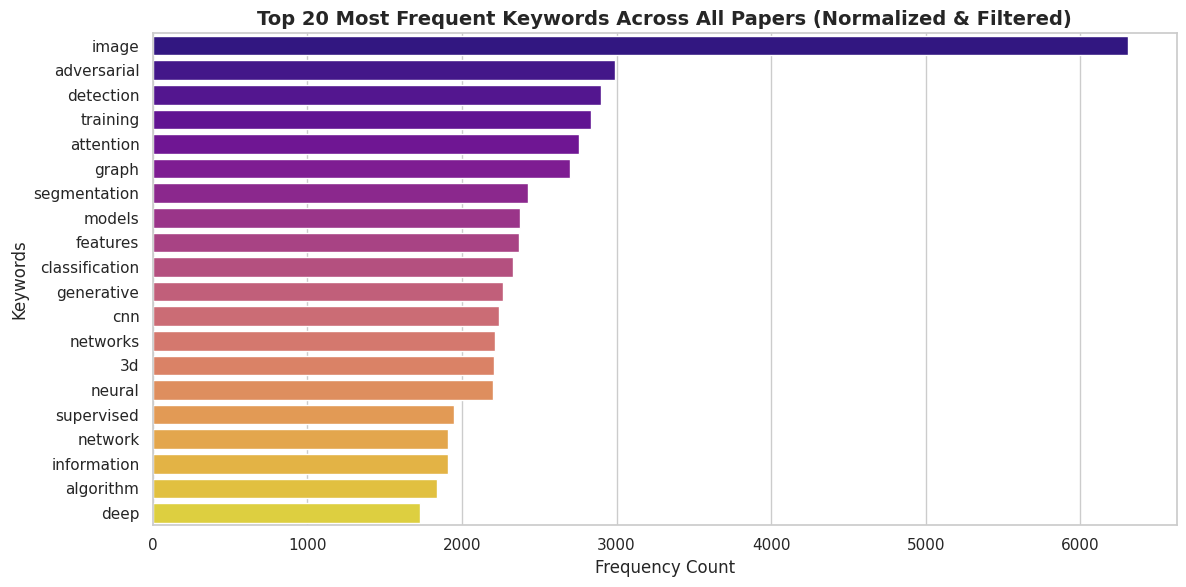


--- Running 4.4.2 Keyphrase-Specific EDA ---


/tmp/ipykernel_16222/2269486304.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_kps_df, x="Count", y="Keyphrase", palette="viridis")


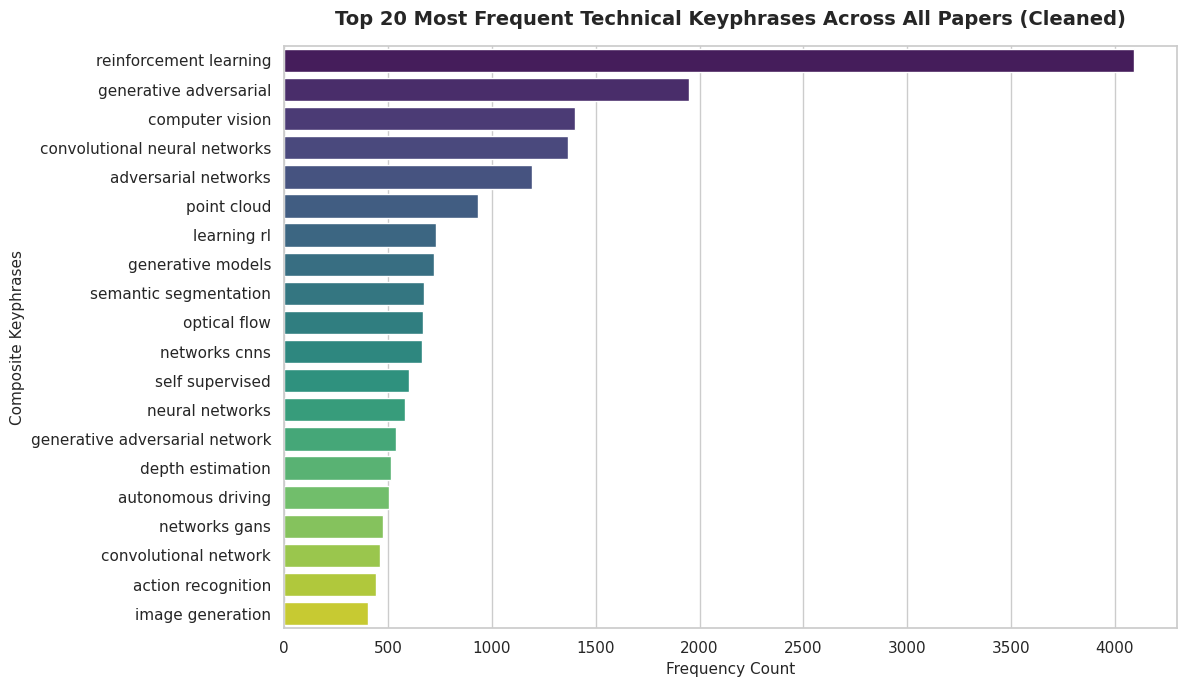


Top 5 Technical Keyphrases for Top 5 Categories:
  📍 cs.CV     : generative adversarial, computer vision, convolutional neural networks, point cloud, semantic segmentation
  📍 cs.LG     : reinforcement learning, learning rl, generative adversarial, adversarial networks, generative models
  📍 stat.ML   : reinforcement learning, graphical models, generative adversarial, adversarial networks, generative models


In [22]:
# =====================================================================
# 4.4 Keyword and Keyphrase EDA (FULLY OPTIMIZED & CLEANED)
# =====================================================================
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Running 4.4 Keyword and Keyphrase EDA ---")

# 1. Comprehensive Academic Fluff Exclusion Mask
academic_noise = [
    "this paper", "the problem", "data", "this work", "recent years", "the-art","our method","the ability",
    "paper", "propose", "method", "results", "using", "study", "approach", "system","a set","end","point clouds",
    "abstract", "model", "methods", "based", "proposed", "used", "provide", "present","the data","the need",
    "the task", "a method", "the field", "the performance", "point",'depth','policy','learning','rl','domain','time','this problem'
]
custom_stop_words = list(set(ENGLISH_STOP_WORDS).union(academic_noise))

# 2. Vocabulary Normalization Map (Merges Plurals and Acronyms to maximize statistical accuracy)
vocab_normalization_map = {
    "images": "image",
    "objects": "object",
    "gans": "generative adversarial networks",
    "rl": "reinforcement learning",
    "deep neural networks": "deep learning"
}

# Ensure column entries are verified loopable lists
final_df["keywords"] = final_df["keywords"].apply(ensure_list)

# 3. Identify and Normalize Single/Multi Keywords
all_keywords = []
for sublist in final_df["keywords"]:
    for kw in sublist:
        kw_clean = str(kw).lower().strip() # Explicit string cast preserves memory safety
        if kw_clean and kw_clean not in custom_stop_words:
            normalized_term = vocab_normalization_map.get(kw_clean, kw_clean)
            all_keywords.append(normalized_term)

kw_counts = Counter(all_keywords)

# Visualize Normalized General Keywords
plt.figure(figsize=(12, 6))
top_kws = pd.DataFrame(kw_counts.most_common(20), columns=["Keyword", "Count"])
sns.barplot(data=top_kws, x="Count", y="Keyword", palette="plasma")
plt.title("Top 20 Most Frequent Keywords Across All Papers (Normalized & Filtered)", fontsize=14, weight="bold")
plt.xlabel("Frequency Count")
plt.ylabel("Keywords")
plt.tight_layout()
plt.show()

print("\n--- Running 4.4.2 Keyphrase-Specific EDA ---")

# 4. Isolate & Normalize ONLY Multi-Word Composite Keyphrases
all_keyphrases = []

# 👇 PASTE IT HERE 👇
final_df["keyphrases"] = final_df["keyphrases"].apply(ensure_list)

for sublist in final_df["keyphrases"]:
    for kp in sublist:
        kp_clean = str(kp).lower().strip()
        if kp_clean and kp_clean not in custom_stop_words:
            normalized_phrase = vocab_normalization_map.get(kp_clean, kp_clean)
            # Enforce multi-word check strictly after consolidation lookup steps
            if len(normalized_phrase.split()) > 1:
                all_keyphrases.append(normalized_phrase)

kp_counts = Counter(all_keyphrases)


# Create DataFrame for the top 20 composite keyphrases
top_kps_df = pd.DataFrame(kp_counts.most_common(20), columns=["Keyphrase", "Count"])

# Visualize keyphrase frequency using bar charts
plt.figure(figsize=(12, 7))
sns.barplot(data=top_kps_df, x="Count", y="Keyphrase", palette="viridis")
plt.title("Top 20 Most Frequent Technical Keyphrases Across All Papers (Cleaned)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Frequency Count", fontsize=11)
plt.ylabel("Composite Keyphrases", fontsize=11)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# Compare Technical Keyphrases Across Top Categories
# -----------------------------------------------------------------
print("\nTop 5 Technical Keyphrases for Top 5 Categories:") # FIX: Matched title description to code output metrics
if "primary_category" in final_df.columns and not final_df["primary_category"].dropna().empty:
    top_5_cats = final_df["primary_category"].value_counts().head(5).index

    for cat in top_5_cats:
        cat_kps = []
        # Filter for rows belonging strictly to active category loop
        category_rows = final_df[final_df["primary_category"] == cat]["keyphrases"]

        for sublist in category_rows:
            for kp in sublist:
                kp_clean = str(kp).lower().strip()
                if kp_clean and kp_clean not in custom_stop_words:
                    norm_kp = vocab_normalization_map.get(kp_clean, kp_clean)
                    if len(norm_kp.split()) > 1:
                        cat_kps.append(norm_kp)

        cat_kp_counts = Counter(cat_kps)
        top_cat_composite = [phrase for phrase, _ in cat_kp_counts.most_common(5)] # Extracts Top-5 cleanly

        phrases_str = ", ".join(top_cat_composite) if top_cat_composite else "No composite keyphrases available"
        print(f"  📍 {str(cat):<10}: {phrases_str}")
else:
    print("⚠️ The primary_category feature column is empty or unmapped in memory.")


In [ ]:
final_df.to_csv("df.csv", index=False)